In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt

# Example n1: Homogeneous slab 

Aim: define an homogeneous material, fill a slab geometry, run a simulation and extract some useful information

# 1. Materials

In [2]:
# Create homogeneous U-water mixture
fuel = openmc.Material(name='Homogeneous U-water mixture')

fuel.set_density('g/cm3', 4)
fuel.add_element('U', 1, enrichment=1) # Add uranium with 5% enrichment
fuel.add_element('O', 4)  
fuel.add_element('H', 4)  
#uwater.add_s_alpha_beta('c_H_in_H2O') # Optional: Add S(α,β) thermal scattering for water

# Create materials object
materials = openmc.Materials([fuel])

materials.export_to_xml()

# 2. Geometry

In [3]:
H = 40 # Total slab length (cm)

# Define slab surfaces
left = openmc.XPlane(x0= -H/2, boundary_type='vacuum')
right = openmc.XPlane(x0= H/2, boundary_type='vacuum')

# Define the slab cell
slab_region = +left & -right
slab_cell = openmc.Cell(region=slab_region)
slab_cell.fill = fuel

# Create universe and geometry
universe = openmc.Universe(cells=[slab_cell])
geometry = openmc.Geometry(universe)

geometry.export_to_xml()

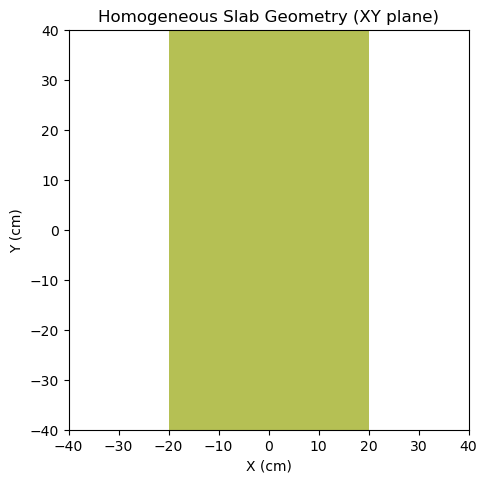

In [4]:
# Create the plot
fig = geometry.plot(basis='xy', origin=(0, 0, 0), width=(2*H, 2*H), pixels=(400, 400))

# Set custom x and y labels
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Homogeneous Slab Geometry (XY plane)')
plt.show()

# 3. Settings

In [5]:
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.batches = 100
settings.inactive = 10
settings.particles = 100

settings.export_to_xml()

# 4. Tallies

In [6]:
tallies = openmc.Tallies()

# --- Filters ---
# 1. Cell
cell_filter = openmc.CellFilter(slab_cell)

# 2. Energy
energy_bins = np.logspace(-5, 7, num=100)  # 100 bins
energy_filter = openmc.EnergyFilter(energy_bins)

# 3. Space 
mesh = openmc.RegularMesh()
mesh.dimension = [100, 1, 1]             
mesh.lower_left = [-H/2, -1e32, -1e32]       
mesh.upper_right = [H/2, 1e32, 1e32] 

#
mesh_filter = openmc.MeshFilter(mesh)

# TALLIES
# --- Tally 1: Energy-dependent Flux ---
flux_tally_E = openmc.Tally(name='Phi(E)')
flux_tally_E.filters = [cell_filter, energy_filter]
flux_tally_E.scores = ['flux']

# --- Tally 2: Space Flux ---
flux_tally_x = openmc.Tally(name='Phi(x)')
flux_tally_x.filters = [mesh_filter]
flux_tally_x.scores = ['flux']

# --- Tally 3: Total reaction rate ---
tot_RR = openmc.Tally(name='PhiSigma_t')
tot_RR.scores = ['total']

# --- Tally 4: Total flux ---
tot_Phi = openmc.Tally(name='Phi_tot')
tot_Phi.scores = ['flux']

# --- Register the tallies ---
tallies = openmc.Tallies([flux_tally_E, flux_tally_x, tot_RR, tot_Phi])

tallies.export_to_xml()

# 5. Run

In [7]:
# Run the simulation and create statepoint file
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

# Postprocessing

In [8]:
sp = openmc.StatePoint('statepoint.100.h5')

In the statepoint there are all the useful information of the simulation

In [9]:
keff = sp.keff

print(f"k-eff = {keff.nominal_value:.5f} +/- {keff.std_dev:.3e}")

k-eff = 0.79146 +/- 8.267e-03


Also, statepoint stores the tally data

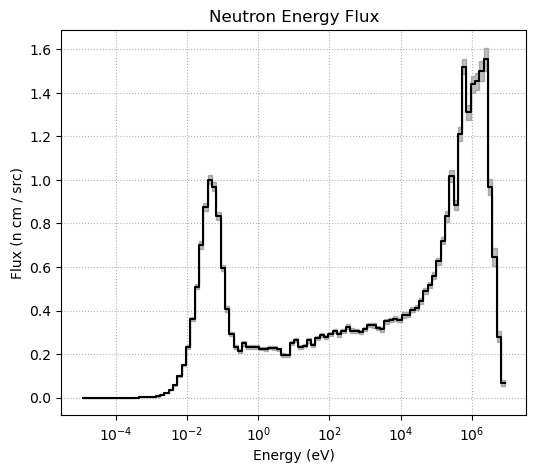

In [10]:
# Energy-dependent flux
flux_tally = sp.get_tally(name='Phi(E)')
flux_vals = flux_tally.mean.flatten()
Uflux_vals = flux_tally.std_dev.flatten()

# Energy bins (midpoints)
energy_mid = 0.5 * (energy_bins[:-1] + energy_bins[1:])

# Plot the flux spectrum
plt.figure(figsize = (6,5))
plt.step(energy_mid, flux_vals, color = "black", where = "pre")
plt.fill_between(energy_mid, flux_vals - Uflux_vals, flux_vals + Uflux_vals, step='pre', color='black', alpha=0.25)
plt.xscale("log")
plt.xlabel("Energy (eV)")
plt.ylabel("Flux (n cm / src)")
plt.title("Neutron Energy Flux")
plt.grid(True, linestyle = ":")
plt.savefig("./phiE.pdf", format = "pdf", bbox_inches = "tight", dpi = 400)
plt.show()

Space flux

/tmp/ipykernel_3399231/2509427884.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


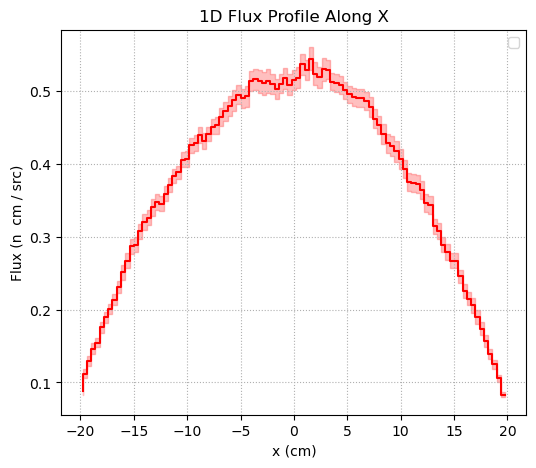

In [11]:
# Space flux
tally = sp.get_tally(name='Phi(x)')
flux_mean = tally.mean.flatten()   # 1D array: [bin0, bin1, ..., binN]
Uflux_mean = tally.std_dev.flatten()

# Access the mesh from the filter
mesh = tally.filters[0].mesh
x_edges = np.linspace(mesh.lower_left[0], mesh.upper_right[0], mesh.dimension[0] + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

plt.figure(figsize = (6,5))
plt.step(x_centers, flux_mean, color = "red", where = "pre")
plt.fill_between(x_centers, flux_mean - Uflux_mean, flux_mean + Uflux_mean, step='pre', color='red', alpha=0.25)
plt.xlabel('x (cm)')
plt.ylabel('Flux (n  cm / src)')
plt.title('1D Flux Profile Along X')
plt.grid(True, linestyle = ":")
plt.legend()
plt.savefig("./phiX.pdf", format = "pdf", bbox_inches = "tight", dpi = 400)
plt.show()

Total reaction rate

In [12]:
tot_RR = sp.get_tally(name='PhiSigma_t').mean.flatten() # reac / source
tot_Phi = sp.get_tally(name='Phi_tot').mean.flatten()   # n cm / source

Sigma_Tot = tot_RR / tot_Phi # 1/cm
MeanFreePath = 1 / Sigma_Tot # cm

print(f"Sigma total = {Sigma_Tot[0]:.3f} cm^-1")
print(f"Mean Free Path = {MeanFreePath[0]:.3f} cm")

Sigma total = 0.675 cm^-1
Mean Free Path = 1.481 cm
